In [75]:
import pandas as pd
import skbio
import numpy as np
import matplotlib.pyplot as plt
import re
import os
import pingouin as pg
from sklearn import manifold
from scipy.spatial import distance
import matplotlib.patches as mpatches
import statistics as stats

In [76]:
### download necessary files
os.system('wget https://ictv.global/sites/default/files/VMR/VMR_MSL40.v2.20251013.xlsx') # ICTV virus metadata

--2025-12-15 14:09:38--  https://ictv.global/sites/default/files/VMR/VMR_MSL40.v2.20251013.xlsx
Resolving ictv.global (ictv.global)... 

18.215.108.91
Connecting to ictv.global (ictv.global)|18.215.108.91|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3502891 (3.3M) [application/vnd.openxmlformats-officedocument.spreadsheetml.sheet]
Saving to: ‘VMR_MSL40.v2.20251013.xlsx.4’

     0K .......... .......... .......... .......... ..........  1%  190K 18s
    50K .......... .......... .......... .......... ..........  2% 1.21M 10s
   100K .......... .......... .......... .......... ..........  4%  545K 9s
   150K .......... .......... .......... .......... ..........  5% 1.24M 7s
   200K .......... .......... .......... .......... ..........  7%  547K 7s
   250K .......... .......... .......... .......... ..........  8% 62.8M 5s
   300K .......... .......... .......... .......... .......... 10% 74.6M 5s
   350K .......... .......... .......... .......... .......... 11% 1.27M 4s
   400K .......... .......... .......... .......... .......... 13% 80.6M 4s
   450K .......... .......... .......... .....

0

In [77]:
### creating list of bacteriophage genera

ictv = pd.read_excel('VMR_MSL40.v2.20251013.xlsx', sheet_name=1)

genus_host = []

for i in ictv[['Genus', 'Host source']].values.tolist():
    if i not in genus_host:
        genus_host.append(i)
    else:
        pass

genus_clean = []
for entry in genus_host:
    if entry[1] == 'invertebrates' or entry[1] == 'invertebrates (S)' or entry[1] == 'invertebrates, plants' or entry[1] == 'invertebrates, vertebrates' or entry[1] == 'vertebrates' or entry[1] == 'vertebrates (S)':
        genus_clean.append(entry)
        
final_genus = []
for i in genus_clean:
    final_genus.append(i[0])

final_genus = list(set(final_genus))

/home/riwama/miniforge3/lib/python3.12/site-packages/openpyxl/worksheet/_read_only.py:85: UserWarning: Data Validation extension is not supported and will be removed
  for idx, row in parser.parse():


In [78]:
### creating dataframes
# loading files as dataframes
viromeDF = pd.read_csv('final_virome_df.csv', sep='\t') # load main virome DF
ViralGenus = list(viromeDF.columns[20:]) # list of viral genera from the virome DF
readCounts = pd.read_csv('Kaiju_total_reads.txt', names=['Reads', 'Run']).astype({'Reads': 'int', 'Run': 'str'}) # load read counts

# base df for statistical analyses
statsDF_genus = viromeDF[['species', 'Run', 'family'] + ViralGenus].merge(readCounts, left_on='Run', right_on='Run').fillna(0).astype(int, errors='ignore') #
ViralGenus = list(set(statsDF_genus.columns).intersection(set(final_genus))) # filtering only genera that infect invertebrates and vertebrates
statDF_T = statsDF_genus[['Run'] + ViralGenus].transpose()
statDF_T.rename(columns=statDF_T.iloc[0], inplace=True)
statDF_T.drop(statDF_T.index[0], inplace=True)

viralCounts = pd.read_csv('viralCountsReads.csv', names=['ViralReads', 'Run']).astype({'ViralReads': 'int', 'Run': 'str'})
statsDF_genus = statsDF_genus.merge(viralCounts, left_on='Run', right_on='Run', how='left')


In [79]:
## calculating basic statiistics. All taxa

per_viral_reads = (statsDF_genus['ViralReads']/statsDF_genus['Reads'])*100
print(max(per_viral_reads))
print(min(per_viral_reads))
print(stats.mean(per_viral_reads))

3.5167631247036937
0.35848762817841273
1.5002576555795084


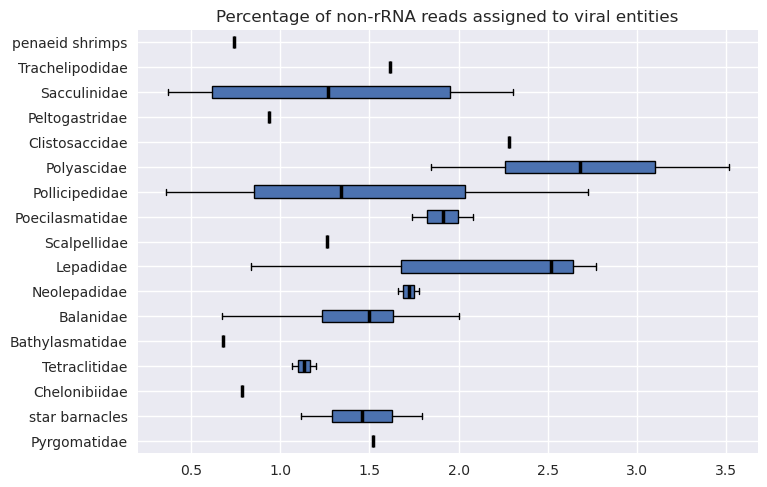

In [80]:
b_families = ['penaeid shrimps','Trachelipodidae','Sacculinidae', 'Peltogastridae', 'Clistosaccidae', 'Polyascidae','Pollicipedidae', 'Poecilasmatidae', 'Scalpellidae', 'Lepadidae', 'Neolepadidae', 'Balanidae', 'Bathylasmatidae', 'Tetraclitidae', 'Chelonibiidae', 'star barnacles', 'Pyrgomatidae']


bars_to_plot = []
labels = []
for family in reversed(b_families):
    bars_to_plot.append((statsDF_genus[statsDF_genus['family'] == family]['ViralReads']/statsDF_genus[statsDF_genus['family'] == family]['Reads'])*100)
    labels.append(family)


fig = plt.figure()


ax1 = fig.add_subplot()

medianprops = dict(linestyle='-.', linewidth=2.5, color='black')

colors = ['#6194D1', '#EF767A']  # choose any colors you like
parts = ax1.boxplot(bars_to_plot, patch_artist = True, tick_labels=labels, orientation='horizontal', medianprops=medianprops, showfliers=False)

parts = ax1.set_title('Percentage of non-rRNA reads assigned to viral entities')

In [ ]:
## Calculating Margalef's and Shannon's indexes


runRichness = {}
runShannon = {}
for i in statDF_T.columns:
    if sum(statDF_T[i].astype(int)) > 0:
        
        runRichness[i] = skbio.diversity.alpha.margalef(statDF_T[i].astype(int)).item() # I chose margalef because menhinick is usede for smaller sample sizes
        runShannon[i] = skbio.diversity.alpha.shannon(statDF_T[i].astype(int), base=None, exp=False).item()


runRichness = pd.DataFrame(runRichness, index=['Richness']).transpose()
runShannon = pd.DataFrame(runShannon, index=['Shannon']).transpose()

viromeDF = viromeDF.merge(runRichness, left_on='Run', right_index=True).merge(runShannon, left_on='Run', right_index=True)


RhizocephalaRichness = viromeDF[viromeDF['infraclass'] == 'Rhizocephala']['Richness']
RhizocephalShannon = viromeDF[viromeDF['infraclass'] == 'Rhizocephala']['Shannon']

ThoracicaRichness = viromeDF[viromeDF['infraclass'] == 'Thoracica']['Richness']
ThoracicaShannon = viromeDF[viromeDF['infraclass'] == 'Thoracica']['Shannon']


print('Rhizocephala Margalef:' + str(stats.mean(RhizocephalaRichness)))
print('Rhizocephala Shannon:' + str(stats.mean(RhizocephalShannon)))

print('Thoracica Margalef:' + str(stats.mean(ThoracicaRichness)))
print('Rhizocephala Shannon:' + str(stats.mean(ThoracicaShannon)))

Rhizocephala margalef:8.75131829811647
Rhizocephala Shannon:2.1684572106320457
Thoracica margalef:9.660174237438818
Rhizocephala Shannon:2.2967137475693797


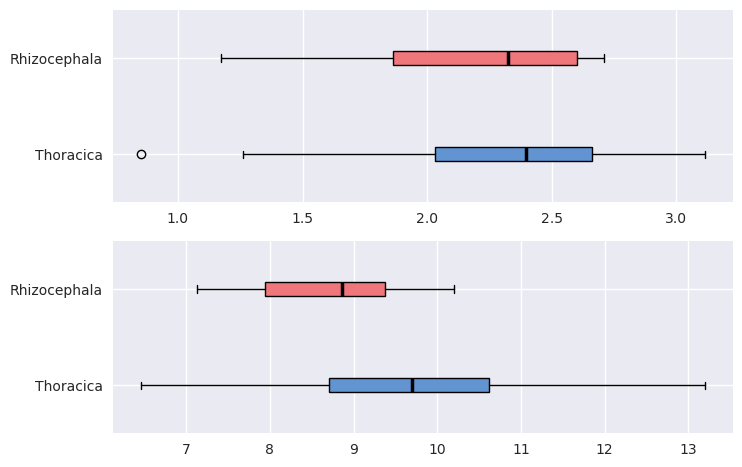

In [82]:
## Plotting richness and diversity
viromeDF = viromeDF.drop(labels=31) # removing an outlier sample with very low richness. N hirsutum transcriptome was sequenced with cirri tissue only and others were sequenced whole body or visceral mass. 

shannon_r = viromeDF[viromeDF['infraclass'] == 'Rhizocephala']['Shannon']
shannon_t = viromeDF[viromeDF['infraclass'] == 'Thoracica']['Shannon']


richness_r = viromeDF[viromeDF['infraclass'] == 'Rhizocephala']['Richness']
richness_t = viromeDF[viromeDF['infraclass'] == 'Thoracica']['Richness']


### this graph is the one that has been chosen


plt.style.use('seaborn-v0_8')

fig = plt.figure()


ax1 = fig.add_subplot(2, 1, 1)

medianprops = dict(linestyle='-.', linewidth=2.5, color='black')

colors = ['#6194D1', '#EF767A']  # choose any colors you like
labels = ['Thoracica', 'Rhizocephala']

parts = ax1.boxplot([shannon_t, shannon_r], patch_artist = True, tick_labels=labels, orientation='horizontal', medianprops=medianprops)

for body, color in zip(parts['boxes'], colors):
     body.set_facecolor(color)

ax2 = fig.add_subplot(2, 1, 2)

medianprops = dict(linestyle='-.', linewidth=2.5, color='black')


colors = ['#6194D1', '#EF767A']  # choose any colors you like
labels = ['Thoracica', 'Rhizocephala']

parts = ax2.boxplot([richness_t, richness_r], patch_artist = True, tick_labels=labels, orientation='horizontal', medianprops=medianprops)




for body, color in zip(parts['boxes'], colors):
     body.set_facecolor(color)

plt.savefig("richness_diversity.pdf", format="pdf", bbox_inches="tight")


In [83]:
hmos = pg.homoscedasticity(viromeDF, dv='Richness', group='infraclass', method='levene', alpha=0.05)
hmos

,W,pval,equal_var
levene,1.361649,0.251371,True


In [84]:
aov_richness = pg.welch_anova(dv='Richness', between='infraclass', data=viromeDF)
aov_richness

,Source,ddof1,ddof2,F,p-unc,np2
0,infraclass,1,17.025359,4.857645,0.041574,0.09104


In [85]:
aov_richness = pg.welch_anova(dv='Shannon', between='infraclass', data=viromeDF)
aov_richness

,Source,ddof1,ddof2,F,p-unc,np2
0,infraclass,1,10.818404,0.385263,0.547654,0.015296


In [87]:
viromeDF_presence =(statsDF_genus[ViralGenus] > 0).astype(int)
statsDF_genus_infra = statsDF_genus.merge(viromeDF, left_on='Run', right_on='Run', how='left')

viromeDF_presence.insert(0, 'infraclass', list(statsDF_genus_infra.set_index('infraclass').index))

In [90]:

rhizocephala_v = []
for i in viromeDF_presence.loc[viromeDF_presence['infraclass'] == 'Rhizocephala'].set_index('infraclass'):
    if sum(list(viromeDF_presence.loc[viromeDF_presence['infraclass'] == 'Rhizocephala'].set_index('infraclass')[i])) > 0:
       rhizocephala_v.append(i)

Thoracica_v = []

for i in viromeDF_presence.loc[viromeDF_presence['infraclass'] == 'Thoracica'].set_index('infraclass'):
    if sum(list(viromeDF_presence.loc[viromeDF_presence['infraclass'] == 'Thoracica'].set_index('infraclass')[i])) > 0:
       Thoracica_v.append(i)


both = list(set(rhizocephala_v[0:-1]) & set(Thoracica_v[0:-1]))

### read ICTV metadata file for genome classification based on genus level taxonomy

ictv_meta = pd.read_excel('VMR_MSL40.v2.20251013.xlsx', sheet_name=1)
ictv_gen = []
for i in ictv_meta['Genome']:
    ictv_gen.append(re.sub(r'-RT', '', (re.sub(r'\(.*\)', '', re.sub(';.*', '', i)))))

Vgenus_genome = dict(zip(ictv_meta['Genus'], ictv_gen))


add_dict_gen = {
                'Abakapovirus':'ssRNA',
                'Apukhovirus':'ssRNA',
                'Batrachovirus':'dsDNA',
                'Chrysovirus':'dsRNA',
                'Condavirus':'ssRNA',
                'Controvirus':'NA',
                'Hypovirus':'dsRNA',
                'Methanothermobacter':'NA',
                'Mucrahivirus':'ssRNA',
                'Obhoarovirus':'ssRNA',
                'Ociwvivirus':'ssRNA',
                'Oenococcus':'NA',
                'Pandoravirus':'dsDNA',
                'Rattus':'NA',
                'Rudivirus':'dsDNA',
                'Staphylococcus':'NA',
                'Streptococcus':'NA',
                'Thyrsuvirus':'ssRNA',
                'Winunavirus':'ssRNA',
                'Wishivirus':'ssRNA'

}   

Vgenus_genome_complete = Vgenus_genome | add_dict_gen

thoracica_genome = {'dsDNA': 0,
                    'ssDNA': 0,
                    'ssRNA': 0,
                    'dsRNA': 0,
                    'NA' : 0}
for  i in Thoracica_v[0:-1]:
    if i != 'NA':
        thoracica_genome[Vgenus_genome_complete[i]] += 1

rhizocephala_genome = {'dsDNA': 0,
                    'ssDNA': 0,
                    'ssRNA': 0,
                    'dsRNA': 0,
                    'NA' : 0}

for i in rhizocephala_v[0:-1]:
    if i != 'NA':
        rhizocephala_genome[Vgenus_genome_complete[i]] += 1

both_genome = {'dsDNA': 0,
                    'ssDNA': 0,
                    'ssRNA': 0,
                    'dsRNA': 0,
                    'NA' : 0}

for i in both:
    if i != 'NA':
        both_genome[Vgenus_genome_complete[i]] += 1


thoracica_only_genome = {'dsDNA': 0,
                    'ssDNA': 0,
                    'ssRNA': 0,
                    'dsRNA': 0,
                    'NA' : 0}


for i in set(Thoracica_v[0:-1]) - set(both[0:-1]):
    if i != 'NA':
        thoracica_only_genome[Vgenus_genome_complete[i]] += 1


rhizocephala_only_genome = {'dsDNA': 0,
                    'ssDNA': 0,
                    'ssRNA': 0,
                    'dsRNA': 0,
                    'NA' : 0}

for i in set(rhizocephala_v[0:-1]) - set(both[0:-1]):
    if i != 'NA':
        rhizocephala_only_genome[Vgenus_genome_complete[i]] += 1

/home/riwama/miniforge3/lib/python3.12/site-packages/openpyxl/worksheet/_read_only.py:85: UserWarning: Data Validation extension is not supported and will be removed
  for idx, row in parser.parse():


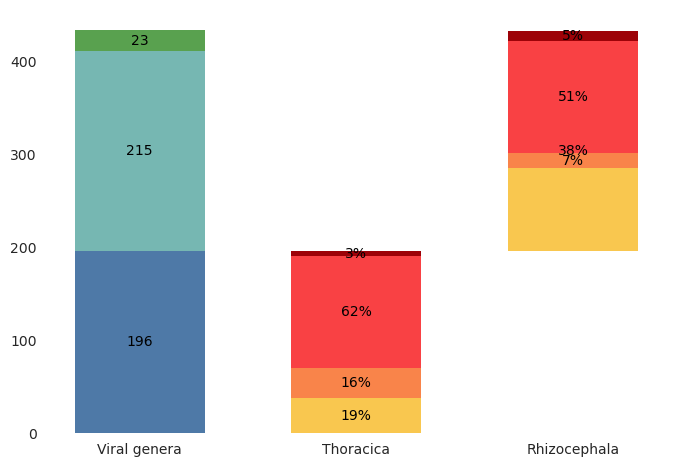

In [91]:
fig, ax = plt.subplots()

width_bars = 0.6



## 1 barra
ax.bar('Viral genera', len(Thoracica_v) - len(both), width=width_bars, color='#4E79A7')
ax.text('Viral genera', 
        (len(Thoracica_v) - len(both)) / 2,  # middle of segment
        str(len(Thoracica_v) - len(both)), 
        ha='center', va='center', color='black')
ax.bar('Viral genera', len(both), width=width_bars, bottom=len(Thoracica_v) - len(both), color='#76B7B2')
ax.text('Viral genera', 
        (len(Thoracica_v) - len(both)) + len(both)/2, 
        str(len(both)), 
        ha='center', va='center', color='black')
ax.bar('Viral genera', len(rhizocephala_v) - len(both), width=width_bars, bottom=len(both) + len(Thoracica_v) - len(both), color='#59A14F')
ax.text('Viral genera', 
        len(Thoracica_v) + (len(rhizocephala_v) - len(both))/2, 
        str(len(rhizocephala_v) - len(both)), 
        ha='center', va='center', color='black')

## 2 barra

ax.bar('Thoracica', thoracica_only_genome['dsDNA'], width=width_bars, color='#F9C74F')
ax.text('Thoracica', 
        thoracica_only_genome['dsDNA']/2,               # middle of segment
        str(round((thoracica_only_genome['dsDNA']/(len(set(Thoracica_v[0:-1]) - set(both[0:-1])))*100))) + '%', 
        ha='center', va='center', color='black')
ax.bar('Thoracica', thoracica_only_genome['ssDNA'], width=width_bars, bottom=thoracica_only_genome['dsDNA'], color='#F9844A')
ax.text('Thoracica', 
        thoracica_only_genome['dsDNA'] + thoracica_only_genome['ssDNA']/2,               # middle of segment
        str(round((thoracica_only_genome['ssDNA']/len(set(Thoracica_v[0:-1]) - set(both[0:-1]))*100))) + '%', 
        ha='center', va='center', color='black'
        )
ax.bar('Thoracica', thoracica_only_genome['ssRNA'], width=width_bars, bottom=thoracica_only_genome['dsDNA'] + thoracica_only_genome['ssDNA'], color='#F94144')
ax.text('Thoracica', 
        thoracica_only_genome['dsDNA'] + thoracica_only_genome['ssDNA'] + thoracica_only_genome['ssRNA']/2, 
        str(round(thoracica_only_genome['ssRNA']/len(set(Thoracica_v[0:-1]) - set(both[0:-1]))*100)) + '%', 
        ha='center', va='center', color='black'
        )
ax.bar('Thoracica', thoracica_only_genome['dsRNA'], width=width_bars, bottom=thoracica_only_genome['dsDNA'] + thoracica_only_genome['ssDNA'] + thoracica_only_genome['ssRNA'], color='#9D0208')

ax.text('Thoracica', 
        thoracica_only_genome['dsDNA'] + thoracica_only_genome['ssDNA'] + thoracica_only_genome['ssRNA'] + thoracica_only_genome['dsRNA']/2, 
        str(round(thoracica_only_genome['dsRNA']/len(set(Thoracica_v[0:-1]) - set(both[0:-1]))*100)) + '%', 
        ha='center', va='center', color='black'
        )

# 3 barra
ax.bar('Rhizocephala', rhizocephala_genome['dsDNA'], width=width_bars, bottom=len(Thoracica_v) - len(both), color='#F9C74F')

ax.text('Rhizocephala', 
        len(Thoracica_v) - len(both)/2,               # middle of segment
        str(round(((rhizocephala_genome['dsDNA']/(len(rhizocephala_v[0:-1]))*100)))) + '%', 
        ha='center', va='center', color='black')

ax.bar('Rhizocephala', rhizocephala_genome['ssDNA'], width=width_bars, bottom=len(Thoracica_v) - len(both) + rhizocephala_genome['dsDNA'], color='#F9844A')

ax.text('Rhizocephala', 
        len(Thoracica_v) - len(both) + rhizocephala_genome['dsDNA'] + rhizocephala_genome['ssDNA']/2,               # middle of segment
        str(round(((rhizocephala_genome['ssDNA']/(len(rhizocephala_v[0:-1]))*100)))) + '%', 
        ha='center', va='center', color='black')


ax.bar('Rhizocephala', rhizocephala_genome['ssRNA'], width=width_bars, bottom=len(Thoracica_v) - len(both) + rhizocephala_genome['dsDNA'] + rhizocephala_genome['ssDNA'], color='#F94144')

ax.text('Rhizocephala', 
        len(Thoracica_v) - len(both) + rhizocephala_genome['dsDNA'] + rhizocephala_genome['ssDNA'] + rhizocephala_genome['ssRNA']/2,               # middle of segment
        str(round(((rhizocephala_genome['ssRNA']/(len(rhizocephala_v[0:-1]))*100)))) + '%', 
        ha='center', va='center', color='black')


ax.bar('Rhizocephala', rhizocephala_genome['dsRNA'], width=width_bars, bottom=len(Thoracica_v) - len(both) + rhizocephala_genome['dsDNA'] + rhizocephala_genome['ssDNA'] + rhizocephala_genome['ssRNA'], color='#9D0208')

ax.text('Rhizocephala', 
        len(Thoracica_v) - len(both) + rhizocephala_genome['dsDNA'] + rhizocephala_genome['ssDNA'] + rhizocephala_genome['ssRNA'] + rhizocephala_genome['dsRNA']/2,               # middle of segment
        str(round(((rhizocephala_genome['dsRNA']/(len(rhizocephala_v[0:-1]))*100)))) + '%', 
        ha='center', va='center', color='black')

ax.grid(False)
ax.set_facecolor("white")
fig.savefig("virome_figure_genometype.pdf")

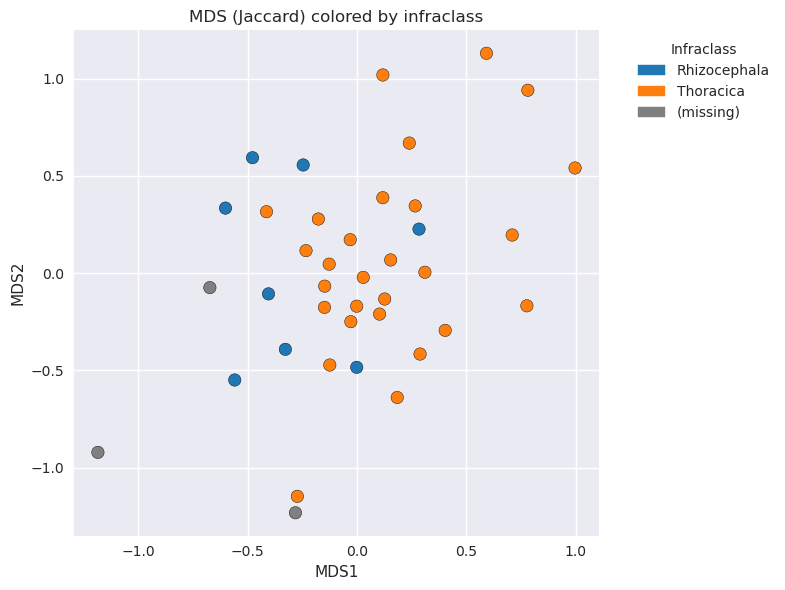

In [92]:
# 1) compute distances and MDS (same as before)
dist = distance.pdist(viromeDF_presence[ViralGenus], metric='braycurtis')
dist_matrix = distance.squareform(dist)

mds = manifold.MDS(
    n_components=2,
    metric=False,
    dissimilarity='precomputed',
    n_init=4,
    max_iter=300,
)
coords = mds.fit_transform(dist_matrix)

# 2) prepare category mapping (robust to NaNs)
groups = viromeDF_presence['infraclass'].astype('category')  # keeps categories and codes
codes = groups.cat.codes.values       # numeric codes; -1 means NaN / missing
categories = groups.cat.categories    # index -> category label

# 3) choose colormap and colors (one color per category)
n_colors = len(categories)
# If there are no categories (edge-case), fall back to 1 color
if n_colors == 0:
    n_colors = 1
cmap = plt.get_cmap('tab10')           # good discrete cmap; tab20 also available
# build color list: pick first n_colors colors from the cmap
colors = [cmap(i % cmap.N) for i in range(n_colors)]

# Map each sample to an RGB tuple; assign a color for missing values (codes == -1)
point_colors = np.array([colors[c] if c >= 0 else (0.5, 0.5, 0.5, 1.0) for c in codes])

# 4) plot
plt.figure(figsize=(8, 6))
plt.scatter(coords[:, 0], coords[:, 1], c=point_colors, s=80, edgecolor='k', linewidth=0.3)

plt.xlabel("MDS1")
plt.ylabel("MDS2")
plt.title("MDS (Jaccard) colored by infraclass")

# 5) legend using patches
handles = []
for i, cat in enumerate(categories):
    handles.append(mpatches.Patch(color=colors[i], label=str(cat)))
# add patch for missing values if present
if (codes == -1).any():
    handles.append(mpatches.Patch(color=(0.5, 0.5, 0.5, 1.0), label='(missing)'))

plt.legend(handles=handles, title='Infraclass', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()


plt.savefig("mds_infraclass.pdf", format="pdf", bbox_inches="tight")
plt.show()